# 13 · GNN · Simulación Ideal

Notebook de sanidad para `TGNN` sobre datos sintéticos construidos a favor de su sesgo inductivo. La idea es verificar si, cuando el target depende explícitamente de la estructura vecinal del grafo, la GNN logra aprender esa señal y superar a un baseline tabular puro.


Nota metodológica: las métricas de este notebook no usan un split espacial estricto. El trabajo se plantea bajo la hipótesis operativa de valuación inmobiliaria más habitual: estimar el precio de una propiedad a partir de comparables cercanos y similares. En ese sentido, no se asume una "verdad espacial" autónoma del precio más allá de la información que ya aportan las propiedades vecinas. Aun así, este enfoque puede sobreestimar el rendimiento del modelo en zonas con pocas muestras comparables o con menor densidad de propiedades similares entre sí.

## Objetivo

- Generar un dataset sintético con coordenadas, features tabulares y un target dependiente del grafo.
- Construir el grafo con `KNHS`, igual que en el pipeline real.
- Comparar un baseline `RandomForestRegressor` contra `TGNN`.
- Confirmar que las aristas se escalan correctamente y que la GNN puede generalizar a splits nuevos bajo el mismo mecanismo generador.


In [91]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [92]:
from pathlib import Path
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from ml_core import load_model_config, save_model_config
from ml_core.evaluation.modelEvaluator import regression_metrics
from ml_core.models.tgnn import TGNN
from ml_core.preprocessing.knhs import KNHS

OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "output" / "13_gnn_simulation_ideal_data"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
SIM_DEVICE = "cpu"


## Configuración

Para esta prueba usamos CPU y un tamaño moderado de datos para privilegiar legibilidad y reproducibilidad por sobre throughput.


In [93]:
simulation_config = {
    "scenario_name": "easy_neighbor_average",
    "train_n": 1200,
    "val_n": 400,
    "test_n": 400,
    "graph_k": 8,
    "graph_radius_km": 2.5,
    "noise_std": 0.02,
    "node_weight": 0.10,
    "neighbor_weight": 1.35,
}

model_config = {
    "edge_dim": 2,
    "device": SIM_DEVICE,
    "tuning_epochs": 120,
    "refit_epochs": 400,
    "fit_epochs": 400,
    "search_type": "random",
    "n_iter": 4,
}

simulation_config, model_config


({'scenario_name': 'easy_neighbor_average',
  'train_n': 1200,
  'val_n': 400,
  'test_n': 400,
  'graph_k': 8,
  'graph_radius_km': 2.5,
  'noise_std': 0.02,
  'node_weight': 0.1,
  'neighbor_weight': 1.35},
 {'edge_dim': 2,
  'device': 'cpu',
  'tuning_epochs': 120,
  'refit_epochs': 400,
  'fit_epochs': 400,
  'search_type': 'random',
  'n_iter': 4})

## Generación Sintética

El target se define como una combinación de:
- una señal local del nodo (`node_signal`), derivada de las features tabulares,
- una señal vecinal (`neighbor_mean`), calculada promediando la señal de los vecinos construidos con `KNHS`,
- y un ruido gaussiano pequeño.

Para respetar el protocolo inductivo del modelo, `train` se genera con su grafo interno y `val/test` se generan con un grafo `train -> target`, igual que el que usa `TGNN.predict()`.
Asi RF y GNN quedan evaluados contra el mismo target, pero solo la GNN puede explotar explicitamente la estructura relacional.


In [94]:
from ml_core.preprocessing.knhs import KNHS, KNHSSchema

def simulated_coords(n_samples=1000, random_state=42):
    """Genera coordenadas [longitud, latitud] agrupadas en clusters compactos."""
    rng = np.random.default_rng(random_state)

    centers = np.array([
        [-58.47, -34.62],
        [-58.43, -34.58],
        [-58.40, -34.61],
        [-58.49, -34.56],
    ], dtype=float)
    cluster_id = rng.integers(0, len(centers), size=n_samples)
    noise = rng.normal(loc=0.0, scale=np.array([0.006, 0.005]), size=(n_samples, 2))
    coords = centers[cluster_id] + noise
    return coords.astype(np.float32)



def simulated_features(schema, n_samples=1000, random_state=42):
    """Genera features tabulares con correlación interna y estructura latente."""
    rng = np.random.default_rng(random_state)

    cluster_id = rng.integers(0, 4, size=n_samples)
    quality = rng.normal(loc=cluster_id * 0.9, scale=0.6, size=n_samples)
    size_latent = rng.normal(loc=70 + cluster_id * 14, scale=10, size=n_samples)
    age_latent = rng.normal(loc=16 - cluster_id * 2, scale=4, size=n_samples)
    amenity_latent = rng.normal(loc=cluster_id * 1.5, scale=0.5, size=n_samples)

    raw_bank = {
        "x1": np.clip(np.round(size_latent + 10 * quality + rng.normal(0, 6, n_samples)), 20, 180),
        "x2": np.clip(np.round(0.75 * size_latent + 6 * quality + rng.normal(0, 5, n_samples)), 15, 150),
        "x3": np.clip(np.round(age_latent + rng.normal(0, 4, n_samples)), 0, 40),
        "x4": np.clip(np.round(55 + 9 * amenity_latent - 4 * quality + rng.normal(0, 7, n_samples)), 5, 120),
        "binaria": (quality + rng.normal(0, 0.6, n_samples)) > np.median(quality),
    }

    data = {}
    for col, dtype in schema.items():
        values = raw_bank[col]
        if dtype is bool:
            data[col] = np.asarray(values, dtype=bool)
        elif dtype is int:
            data[col] = np.asarray(np.round(values), dtype=np.int64)
        elif dtype is float:
            data[col] = np.asarray(values, dtype=float)
        else:
            data[col] = np.asarray(values)

    return pd.DataFrame(data)



def build_graph_frame(X_df, coords_deg_longlat):
    coords_arr = np.asarray(coords_deg_longlat, dtype=float)
    if coords_arr.ndim != 2 or coords_arr.shape[1] != 2:
        raise ValueError(
            "coords debe tener shape (n, 2) con columnas [longitud, latitud]. "
            f"Recibido: {coords_arr.shape}."
        )

    graph = X_df.copy().reset_index(drop=True)
    graph["lat_deg"] = coords_arr[:, 1]
    graph["lon_deg"] = coords_arr[:, 0]
    return graph



def compute_node_signal(X_df):
    """Senal tabular propia del nodo antes de agregar informacion vecinal."""
    x1 = X_df["x1"].to_numpy(dtype=float)
    x2 = X_df["x2"].to_numpy(dtype=float)
    x3 = X_df["x3"].to_numpy(dtype=float)
    x4 = X_df["x4"].to_numpy(dtype=float)
    binaria = X_df["binaria"].to_numpy(dtype=float)
    return (
        0.020 * x1
        + 0.012 * x2
        - 0.010 * x3
        + 0.010 * x4
        + 0.20 * binaria
    )


def zscore_with_reference(values, reference_values=None):
    values_arr = np.asarray(values, dtype=float)
    ref_arr = values_arr if reference_values is None else np.asarray(reference_values, dtype=float)
    return (values_arr - ref_arr.mean()) / (ref_arr.std() + 1e-8)


def aggregate_neighbor_mean(node_signal, edge_index, n_nodes):
    neighbor_sum = np.zeros(n_nodes, dtype=float)
    neighbor_count = np.zeros(n_nodes, dtype=float)
    src, dst = edge_index
    for src_i, dst_i in zip(src, dst):
        neighbor_sum[int(dst_i)] += node_signal[int(src_i)]
        neighbor_count[int(dst_i)] += 1.0
    return neighbor_sum / np.clip(neighbor_count, 1.0, None)


def simulate_graph_target(
    X_df,
    coords_deg_longlat,
    random_state=42,
    k=8,
    radius_km=2.5,
    noise_std=0.02,
    node_weight=0.10,
    neighbor_weight=1.35,
    source_X_df=None,
    source_coords_deg_longlat=None,
):
    """Genera un target relacional compatible con el protocolo inductivo train->target."""
    rng = np.random.default_rng(random_state)

    feature_cols_local = list(X_df.columns)
    builder_local = KNHS(
        schema=KNHSSchema(
            lat_col="lat_deg",
            lon_col="lon_deg",
            similarity_feature_cols=list(feature_cols_local),
        ),
        radius_km=radius_km,
        k=k,
        feature_distance_mode="euclidean",
        add_reverse=True,
        scale_edge_features=False,
    )

    if source_X_df is None:
        graph_df = build_graph_frame(X_df, coords_deg_longlat)
        edge_index_local, _ = builder_local.build(graph_df, scale_edge_attr=False)
        raw_node_signal = compute_node_signal(X_df)
        node_signal = zscore_with_reference(raw_node_signal)
        neighbor_mean = aggregate_neighbor_mean(node_signal, edge_index_local, len(X_df))
        neighbor_mean = zscore_with_reference(neighbor_mean)
        log_precio = (
            12.0
            + node_weight * node_signal
            + neighbor_weight * neighbor_mean
            + rng.normal(0.0, noise_std, size=len(X_df))
        )
        return log_precio.astype(np.float32)

    source_graph_df = build_graph_frame(source_X_df, source_coords_deg_longlat)
    target_graph_df = build_graph_frame(X_df, coords_deg_longlat)
    _, edge_index_local, _, target_mask = builder_local.build_cross_split(
        source_graph_df,
        target_graph_df,
        scale_edge_attr=False,
    )

    raw_source_signal = compute_node_signal(source_X_df)
    raw_target_signal = compute_node_signal(X_df)
    combined_node_signal = np.concatenate([
        zscore_with_reference(raw_source_signal, reference_values=raw_source_signal),
        zscore_with_reference(raw_target_signal, reference_values=raw_source_signal),
    ])
    neighbor_mean = aggregate_neighbor_mean(combined_node_signal, edge_index_local, len(combined_node_signal))
    neighbor_mean = zscore_with_reference(
        neighbor_mean,
        reference_values=neighbor_mean[: len(source_X_df)],
    )

    log_precio_full = (
        12.0
        + node_weight * combined_node_signal
        + neighbor_weight * neighbor_mean
        + rng.normal(0.0, noise_std, size=len(combined_node_signal))
    )
    return log_precio_full[target_mask].astype(np.float32)



def build_simulated_geodataframe(X_df, coords_deg_longlat, log_target):
    gdf = X_df.copy().reset_index(drop=True)
    coords_arr = np.asarray(coords_deg_longlat, dtype=float)
    gdf["longitud"] = coords_arr[:, 0]
    gdf["latitud"] = coords_arr[:, 1]
    gdf["log_precio"] = np.asarray(log_target, dtype=float)
    gdf["precio"] = np.exp(gdf["log_precio"])
    return gpd.GeoDataFrame(
        gdf,
        geometry=gpd.points_from_xy(gdf["longitud"], gdf["latitud"]),
        crs="EPSG:4326",
    )



In [95]:
feature_schema = {
    "x1": int,
    "x2": int,
    "x3": int,
    "x4": int,
    "binaria": bool,
}

target_col = "log_precio"
coord_cols = ["longitud", "latitud"]
feature_cols = ["x1", "x2", "x3", "x4", "binaria"]

coords_sim_train = simulated_coords(n_samples=simulation_config["train_n"], random_state=42)
X_sim_train = simulated_features(feature_schema, n_samples=simulation_config["train_n"], random_state=42)
y_sim_train = simulate_graph_target(
    X_sim_train,
    coords_sim_train,
    random_state=42,
    k=simulation_config["graph_k"],
    radius_km=simulation_config["graph_radius_km"],
    noise_std=simulation_config["noise_std"],
    node_weight=simulation_config["node_weight"],
    neighbor_weight=simulation_config["neighbor_weight"],
)
gdf_train = build_simulated_geodataframe(X_sim_train, coords_sim_train, y_sim_train)

coords_sim_val = simulated_coords(n_samples=simulation_config["val_n"], random_state=43)
X_sim_val = simulated_features(feature_schema, n_samples=simulation_config["val_n"], random_state=43)
y_sim_val = simulate_graph_target(
    X_sim_val,
    coords_sim_val,
    random_state=43,
    k=simulation_config["graph_k"],
    radius_km=simulation_config["graph_radius_km"],
    noise_std=simulation_config["noise_std"],
    node_weight=simulation_config["node_weight"],
    neighbor_weight=simulation_config["neighbor_weight"],
    source_X_df=X_sim_train,
    source_coords_deg_longlat=coords_sim_train,
)
gdf_val = build_simulated_geodataframe(X_sim_val, coords_sim_val, y_sim_val)

coords_sim_test = simulated_coords(n_samples=simulation_config["test_n"], random_state=44)
X_sim_test = simulated_features(feature_schema, n_samples=simulation_config["test_n"], random_state=44)
y_sim_test = simulate_graph_target(
    X_sim_test,
    coords_sim_test,
    random_state=44,
    k=simulation_config["graph_k"],
    radius_km=simulation_config["graph_radius_km"],
    noise_std=simulation_config["noise_std"],
    node_weight=simulation_config["node_weight"],
    neighbor_weight=simulation_config["neighbor_weight"],
    source_X_df=X_sim_train,
    source_coords_deg_longlat=coords_sim_train,
)
gdf_test = build_simulated_geodataframe(X_sim_test, coords_sim_test, y_sim_test)

split_summary = pd.DataFrame(
    {
        "split": ["train", "val", "test"],
        "n_rows": [len(gdf_train), len(gdf_val), len(gdf_test)],
        "precio_mean": [gdf_train["precio"].mean(), gdf_val["precio"].mean(), gdf_test["precio"].mean()],
        "precio_std": [gdf_train["precio"].std(), gdf_val["precio"].std(), gdf_test["precio"].std()],
    }
)
split_summary



,split,n_rows,precio_mean,precio_std
0,train,1200,407586.068610,556485.635699
1,val,400,428254.363039,544896.509934
2,test,400,436412.936076,557472.093271


In [96]:
X_train = gdf_train[feature_cols]
y_train = gdf_train[target_col]
coords_train = gdf_train[coord_cols].to_numpy()

X_val = gdf_val[feature_cols]
y_val = gdf_val[target_col]
coords_val = gdf_val[coord_cols].to_numpy()

X_test = gdf_test[feature_cols]
y_test = gdf_test[target_col]
coords_test = gdf_test[coord_cols].to_numpy()

gdf_train.head()


,x1,x2,x3,x4,binaria,longitud,latitud,log_precio,precio,geometry
0,78,50,11,55,False,-58.462513,-34.621262,10.412585,33275.785806,POINT (-58.46251 -34.62126)
1,125,83,7,62,True,-58.487820,-34.572048,12.967807,428397.514664,POINT (-58.48782 -34.57205)
2,139,99,23,66,False,-58.406937,-34.611469,13.498915,728625.177260,POINT (-58.40694 -34.61147)
3,94,56,15,79,False,-58.436432,-34.576427,11.434125,92422.427182,POINT (-58.43643 -34.57643)
4,83,63,19,69,False,-58.418015,-34.585884,10.841552,51100.613434,POINT (-58.41801 -34.58588)


## Escalado de Features

Antes de entrenar `TGNN`, escalamos las features numéricas usando solo `train` y aplicamos esa transformación a `val/test`. Esto ayuda a estabilizar la optimización sin cambiar la regla generadora del target.


In [97]:
numeric_feature_cols = [
    col for col in feature_cols
    if not pd.api.types.is_bool_dtype(X_train[col])
]

feature_scaler = StandardScaler()
float_cast = {col: float for col in numeric_feature_cols}

X_train = X_train.copy().astype(float_cast)
X_val = X_val.copy().astype(float_cast)
X_test = X_test.copy().astype(float_cast)

X_train_scaled = feature_scaler.fit_transform(
    X_train[numeric_feature_cols]
)
X_val_scaled = feature_scaler.transform(
    X_val[numeric_feature_cols]
)
X_test_scaled = feature_scaler.transform(
    X_test[numeric_feature_cols]
)

X_train.loc[:, numeric_feature_cols] = pd.DataFrame(
    X_train_scaled,
    columns=numeric_feature_cols,
    index=X_train.index,
)
X_val.loc[:, numeric_feature_cols] = pd.DataFrame(
    X_val_scaled,
    columns=numeric_feature_cols,
    index=X_val.index,
)
X_test.loc[:, numeric_feature_cols] = pd.DataFrame(
    X_test_scaled,
    columns=numeric_feature_cols,
    index=X_test.index,
)

pd.DataFrame({
    "feature": numeric_feature_cols,
    "train_mean_scaled": X_train[numeric_feature_cols].mean().round(4).to_numpy(),
    "train_std_scaled": X_train[numeric_feature_cols].std(ddof=0).round(4).to_numpy(),
})


,feature,train_mean_scaled,train_std_scaled
0,x1,0.0,1.0
1,x2,-0.0,1.0
2,x3,-0.0,1.0
3,x4,0.0,1.0


## Diagnóstico del Grafo

Antes de entrenar el modelo, conviene verificar que la construcción del grafo tenga sentido y que el escalado de aristas quede efectivamente aplicado.


In [98]:
from ml_core.preprocessing.knhs import KNHS, KNHSSchema

k_neighbors = simulation_config["graph_k"]
radius_km = simulation_config["graph_radius_km"]

graph_train = build_graph_frame(X_train, coords_train)
builder = KNHS(
    schema=KNHSSchema(
        lat_col="lat_deg",
        lon_col="lon_deg",
        similarity_feature_cols=list(feature_cols),
    ),
    radius_km=radius_km,
    k=k_neighbors,
    feature_distance_mode="euclidean",
    add_reverse=True,
)

edge_index_raw, edge_attr_raw = builder.build(graph_train, scale_edge_attr=False)
edge_index_scaled, edge_attr_scaled = builder.build(graph_train, fit_edge_scaler=True)

graph_summary = pd.DataFrame(
    {
        "metric": [
            "n_nodes_train",
            "n_edges_train",
            "dist_km_mean_raw",
            "dist_feat_mean_raw",
            "dist_km_std_scaled",
            "dist_feat_std_scaled",
        ],
        "value": [
            len(graph_train),
            edge_index_raw.shape[1],
            float(edge_attr_raw[:, 0].mean()),
            float(edge_attr_raw[:, 1].mean()),
            float(edge_attr_scaled[:, 0].std()),
            float(edge_attr_scaled[:, 1].std()),
        ],
    }
)
graph_summary


,metric,value
0,n_nodes_train,1200.000000
1,n_edges_train,19200.000000
2,dist_km_mean_raw,0.995383
3,dist_feat_mean_raw,0.573996
4,dist_km_std_scaled,1.000000
5,dist_feat_std_scaled,1.000000


## Baseline Tabular

Para que el resultado sea interpretable, primero medimos un `RandomForestRegressor` que solo ve las features tabulares del nodo y no recibe el grafo.


In [99]:
rf_baseline = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)
rf_baseline.fit(X_train.astype(float), y_train)

rf_val_pred_log = rf_baseline.predict(X_val.astype(float))
rf_test_pred_log = rf_baseline.predict(X_test.astype(float))

rf_metrics_val = regression_metrics(np.exp(y_val), np.exp(rf_val_pred_log))
rf_metrics_test = regression_metrics(np.exp(y_test), np.exp(rf_test_pred_log))

pd.DataFrame([
    {"model": "RF baseline", "split": "val", **rf_metrics_val},
    {"model": "RF baseline", "split": "test", **rf_metrics_test},
])


,model,split,rmse,mae,r2,bias,median_abs_error,mape
0,RF baseline,val,73113.806454,33945.495553,0.981951,9462.835988,9841.573727,8.824138
1,RF baseline,test,72742.582156,36786.484180,0.982931,2674.335545,12397.014399,8.967835


## Tuning del GNN

Esta version usa un escenario deliberadamente facil para la red: menos ruido, target muy dominado por la senal vecinal y una grilla chica. Si la GNN no funciona bien aca, la sospecha principal deberia pasar a ser implementativa/arquitectonica y no de datos reales.


In [105]:
config_path = PROJECT_ROOT / "notebooks" / "cache" / "gnn_ideal_simulation_easy_inductive_best_config.json"
saved_config = load_model_config(config_path)

param_grid = {
    "hidden": [32, 64, 96],
    "num_layers": [1, 2],
    "num_heads": [1, 2, 4, 8],
    "dropout": [0.0, 0.05],
    "lr": [1e-3, 2e-3],
    "weight_decay": [0.0, 1e-6],
    "loss_name": ["huber"],
    "huber_delta": [0.5],
    "grad_clip_norm": [None, 5.0],
}

if saved_config is None:
    tuning_model = TGNN(
        feature_names=feature_cols ,
        edge_dim=model_config["edge_dim"],
        graph_builder=builder,
        device=model_config["device"],
        patience=40,
        loss_name="huber",
        huber_delta=0.5,
        grad_clip_norm=5.0,
    )
    print("SIM_DEVICE:", model_config["device"])
    print("tuning_model.device:", tuning_model.device)
    assert str(tuning_model.device) == model_config["device"]

    tuning_model.tune_hyperparameters(
        X_train,
        y_train,
        coords_train,
        X_val=X_val,
        y_val=y_val,
        coords_val=coords_val,
        param_grid=param_grid,
        search_type=model_config["search_type"],
        n_iter=model_config["n_iter"],
        optimize_metric="mape",
        epochs=model_config["tuning_epochs"],
        refit_epochs=model_config["refit_epochs"],
        random_state=42,
    )

    save_model_config(
        tuning_model,
        config_path,
        extra={
            "target": target_col,
            "features": feature_cols,
            "simulation_config": simulation_config,
            "graph_params": {
                "k_neighbors": k_neighbors,
                "radius_km": radius_km,
                "graph_distance": "euclidean",
            },
            "simulation_protocol": "inductive_train_to_target",
        },
    )
    saved_config = load_model_config(config_path)

best_config = saved_config.get("best_params_", {})
if not best_config:
    raise ValueError(f"No se encontro best_params_ en {config_path}")

best_config


SIM_DEVICE: cpu
tuning_model.device: cpu
Ejecutando 4 configuraciones (search_type=random, total_grid=384).
Entrenando config {'hidden': 64, 'num_layers': 1, 'num_heads': 4, 'dropout': 0.05, 'lr': 0.001, 'weight_decay': 0.0, 'loss_name': 'huber', 'huber_delta': 0.5, 'grad_clip_norm': None}
Entrenando config {'hidden': 32, 'num_layers': 1, 'num_heads': 4, 'dropout': 0.0, 'lr': 0.001, 'weight_decay': 1e-06, 'loss_name': 'huber', 'huber_delta': 0.5, 'grad_clip_norm': None}
Entrenando config {'hidden': 64, 'num_layers': 2, 'num_heads': 8, 'dropout': 0.05, 'lr': 0.001, 'weight_decay': 1e-06, 'loss_name': 'huber', 'huber_delta': 0.5, 'grad_clip_norm': None}
Entrenando config {'hidden': 96, 'num_layers': 1, 'num_heads': 4, 'dropout': 0.0, 'lr': 0.002, 'weight_decay': 1e-06, 'loss_name': 'huber', 'huber_delta': 0.5, 'grad_clip_norm': 5.0}


{'hidden': 64,
 'num_layers': 2,
 'num_heads': 8,
 'dropout': 0.05,
 'lr': 0.001,
 'weight_decay': 1e-06,
 'loss_name': 'huber',
 'huber_delta': 0.5,
 'grad_clip_norm': None}

## Entrenamiento Final


In [106]:
print("Mejor config:", best_config)
print("Cache:", config_path)

model = TGNN(
    feature_names=feature_cols,
    edge_dim=model_config["edge_dim"],
    graph_builder=builder,
    device=model_config["device"],
    hidden=64,
    num_layers=1,
    num_heads=1,
    dropout=float(best_config["dropout"]),
    lr=float(best_config["lr"]),
    weight_decay=float(best_config["weight_decay"]),
    patience=300,
    loss_name="huber",
    huber_delta=float(best_config["huber_delta"]),
    grad_clip_norm=(None if best_config["grad_clip_norm"] is None else float(best_config["grad_clip_norm"])),
)
_ = model.fit(
    X_train,
    y_train,
    coords_train,
    epochs=15000,
)

if not model.graph_builder_.edge_scaler_fitted_:
    raise RuntimeError("El edge_scaler del graph_builder no quedó fitted después de fit().")

edge_scaler_check = pd.DataFrame(
    {
        "stat": ["edge_mean_km", "edge_mean_feat", "edge_std_km", "edge_std_feat"],
        "value": [
            float(model.edge_attr_[:, 0].mean()),
            float(model.edge_attr_[:, 1].mean()),
            float(model.edge_attr_[:, 0].std()),
            float(model.edge_attr_[:, 1].std()),
        ],
    }
)
edge_scaler_check


Mejor config: {'hidden': 64, 'num_layers': 2, 'num_heads': 8, 'dropout': 0.05, 'lr': 0.001, 'weight_decay': 1e-06, 'loss_name': 'huber', 'huber_delta': 0.5, 'grad_clip_norm': None}
Cache: /home/saneliges/Escritorio/PredictorPrecioMetroCuadradoAlquileres/notebooks/cache/gnn_ideal_simulation_easy_inductive_best_config.json
Early stopping en epoch 3665, best loss=0.075796


,stat,value
0,edge_mean_km,1.589457e-09
1,edge_mean_feat,-1.589457e-09
2,edge_std_km,1.000000e+00
3,edge_std_feat,1.000000e+00


<Axes: xlabel='epoch'>

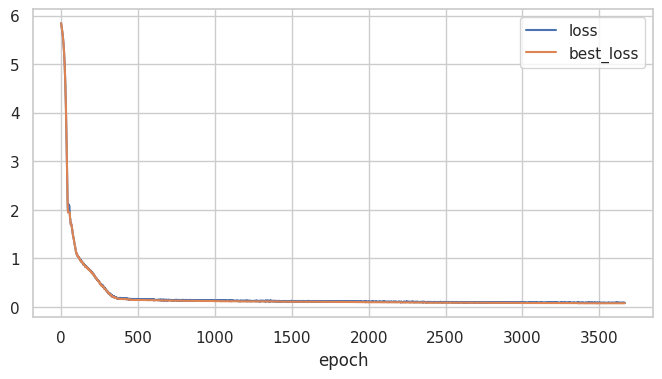

In [107]:
history = pd.DataFrame(model.history_)
history.tail()
history.plot(x="epoch", y=["loss", "best_loss"], figsize=(8, 4))


In [108]:
gnn_val_pred_log = model.predict(X_val, coords_val).reshape(-1)
gnn_test_pred_log = model.predict(X_test, coords_test).reshape(-1)
gnn_train_pred_log = model.predict(X_train, coords_train).reshape(-1)

gnn_metrics_train = regression_metrics(np.exp(y_train), np.exp(gnn_train_pred_log))
gnn_metrics_val = regression_metrics(np.exp(y_val), np.exp(gnn_val_pred_log))
gnn_metrics_test = regression_metrics(np.exp(y_test), np.exp(gnn_test_pred_log))

results_df = pd.DataFrame([
    {"model": "RF baseline", "split": "val", **rf_metrics_val},
    {"model": "RF baseline", "split": "test", **rf_metrics_test},
    {"model": "TGNN", "split": "train", **gnn_metrics_train},
    {"model": "TGNN", "split": "val", **gnn_metrics_val},
    {"model": "TGNN", "split": "test", **gnn_metrics_test},
])
results_df


,model,split,rmse,mae,r2,bias,median_abs_error,mape
0,RF baseline,val,73113.806454,33945.495553,0.981951,9462.835988,9841.573727,8.824138
1,RF baseline,test,72742.582156,36786.484180,0.982931,2674.335545,12397.014399,8.967835
2,TGNN,train,65783.179327,29454.230417,0.986014,23748.241107,7306.159897,6.440890
3,TGNN,val,76961.886216,34866.601120,0.980001,25663.843814,8433.603592,7.509072
4,TGNN,test,53975.560079,28883.944432,0.990602,21127.405565,10134.174380,7.110810


## Visualización Rápida

Si la simulación está bien planteada, deberíamos ver una relación bastante ajustada entre precios reales y predichos, especialmente en validación y test.


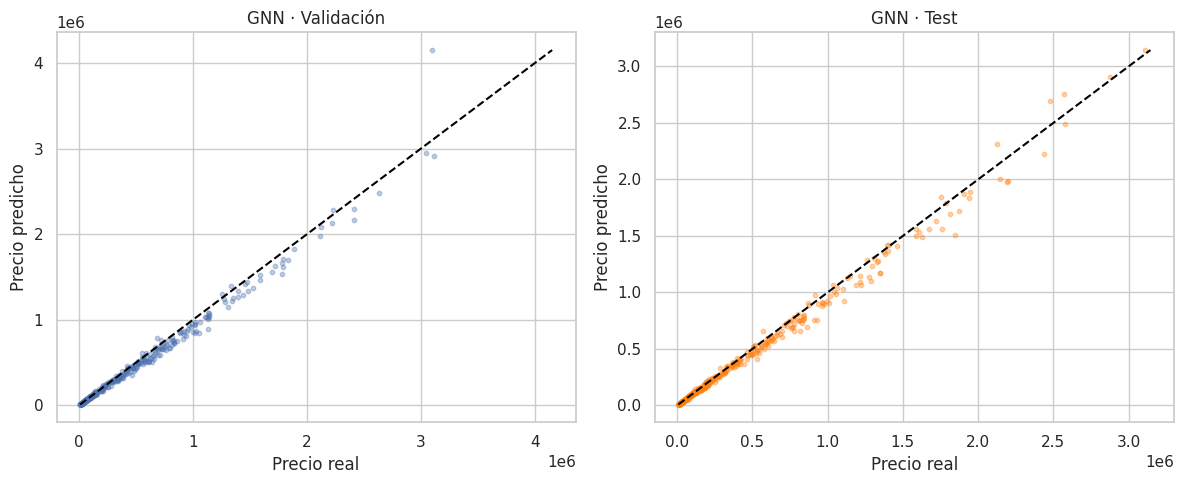

In [109]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(np.exp(y_val), np.exp(gnn_val_pred_log), s=10, alpha=0.35)
val_min = min(np.exp(y_val).min(), np.exp(gnn_val_pred_log).min())
val_max = max(np.exp(y_val).max(), np.exp(gnn_val_pred_log).max())
axes[0].plot([val_min, val_max], [val_min, val_max], linestyle="--", color="black")
axes[0].set_title("GNN · Validación")
axes[0].set_xlabel("Precio real")
axes[0].set_ylabel("Precio predicho")

axes[1].scatter(np.exp(y_test), np.exp(gnn_test_pred_log), s=10, alpha=0.35, color="tab:orange")
test_min = min(np.exp(y_test).min(), np.exp(gnn_test_pred_log).min())
test_max = max(np.exp(y_test).max(), np.exp(gnn_test_pred_log).max())
axes[1].plot([test_min, test_max], [test_min, test_max], linestyle="--", color="black")
axes[1].set_title("GNN · Test")
axes[1].set_xlabel("Precio real")
axes[1].set_ylabel("Precio predicho")

plt.tight_layout()
plt.show()


## Conclusión Esperada

Si `TGNN` supera al baseline tabular bajo este protocolo inductivo consistente, la lectura natural es: la implementación del modelo sí puede capturar señales relacionales cuando el target realmente depende del grafo.
En ese caso, el problema con los datos reales probablemente no sea que la arquitectura esté rota, sino que la señal vecinal real sea más débil, más ruidosa o esté mal alineada con la forma en que hoy construimos el grafo.
